In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = "/content/retail_sales_dataset (1).csv"
df = pd.read_csv(path)
df

,order_id,date,region,category,product,units_sold,unit_price,discount,revenue,customer_age,customer_gender,payment_mode,returns
0,1001,2023-01-03,North,Electronics,Laptop,2,55000,0.05,104500,34,Male,Credit Card,0
1,1002,2023-01-05,South,Clothing,Shirt,10,899,0.10,8091,22,Female,UPI,1
2,1003,2023-01-07,East,Furniture,Chair,3,4500,0.00,13500,45,Male,Cash,0
3,1004,2023-01-09,West,Electronics,Smartphone,5,22000,0.08,101200,29,Female,Debit Card,0
4,1005,2023-01-12,North,Grocery,Rice,20,250,0.00,5000,38,Female,Cash,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,2023-12-16,West,Clothing,Saree,9,3000,0.10,24300,47,Female,Cash,0
116,1117,2023-12-19,North,Electronics,Smartphone,7,22000,0.08,141680,31,Male,UPI,0
117,1118,2023-12-22,South,Furniture,Bed,2,35000,0.10,63000,55,Female,Credit Card,0
118,1119,2023-12-25,East,Grocery,Tea,30,180,0.00,5400,38,Male,Cash,0


In [ ]:
df.head()

,order_id,date,region,category,product,units_sold,unit_price,discount,revenue,customer_age,customer_gender,payment_mode,returns
0,1001,2023-01-03,North,Electronics,Laptop,2,55000,0.05,104500,34,Male,Credit Card,0
1,1002,2023-01-05,South,Clothing,Shirt,10,899,0.10,8091,22,Female,UPI,1
2,1003,2023-01-07,East,Furniture,Chair,3,4500,0.00,13500,45,Male,Cash,0
3,1004,2023-01-09,West,Electronics,Smartphone,5,22000,0.08,101200,29,Female,Debit Card,0
4,1005,2023-01-12,North,Grocery,Rice,20,250,0.00,5000,38,Female,Cash,0


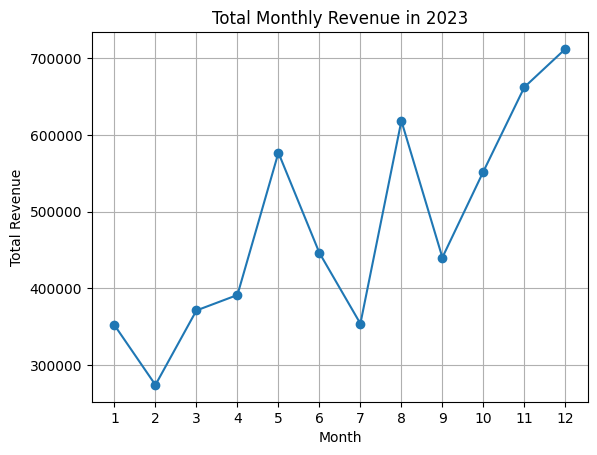

In [ ]:
df["date"] = pd.to_datetime(df["date"])
x = df[df["date"].dt.year == 2023].copy()

revenue = (x.groupby(x["date"].dt.month)["revenue"].sum())
plt.plot(revenue.index,revenue.values,marker = "o")

plt.title("Total Monthly Revenue in 2023")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [4]:
region_revenue = df.groupby("region")["revenue"].sum()

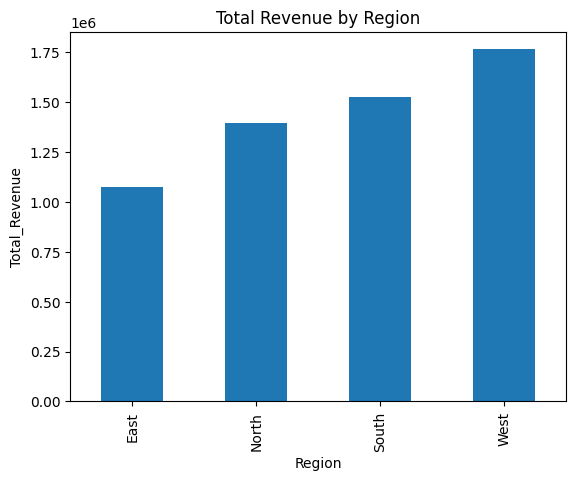

In [5]:
region_revenue.plot(kind = "bar")
plt.xlabel("Region")
plt.ylabel("Total_Revenue")
plt.title("Total Revenue by Region")
plt.show()


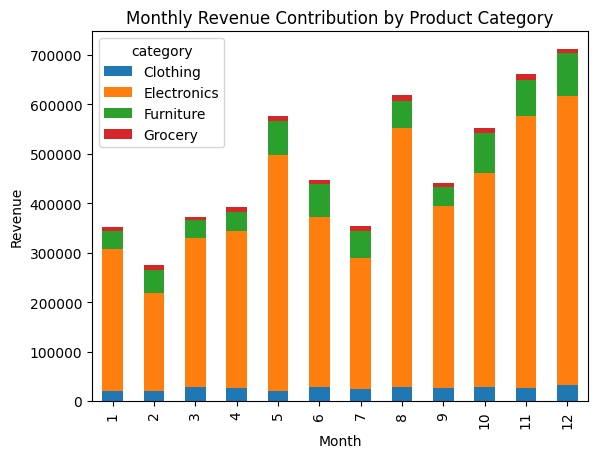

In [9]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

monthly_category = df.pivot_table(
    index="month",
    columns="category",
    values="revenue",
    aggfunc="sum"
)

monthly_category.plot(kind="bar", stacked=True)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Contribution by Product Category")
plt.show()

In [10]:
category_revenue = df.groupby("category")["revenue"].sum()
print(category_revenue)

category
Clothing        308752
Electronics    4647225
Furniture       681000
Grocery         113390
Name: revenue, dtype: int64


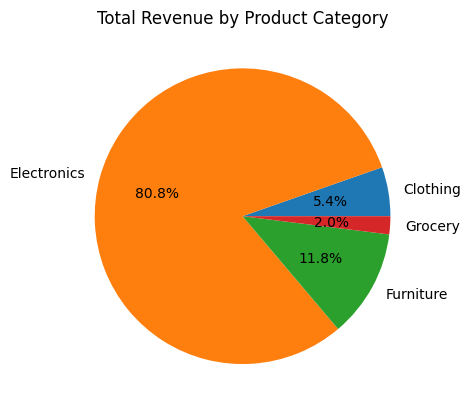

In [11]:
category_revenue.plot(kind = "pie", autopct = "%1.1f%%")
plt.ylabel("")
plt.title("Total Revenue by Product Category")
plt.show()


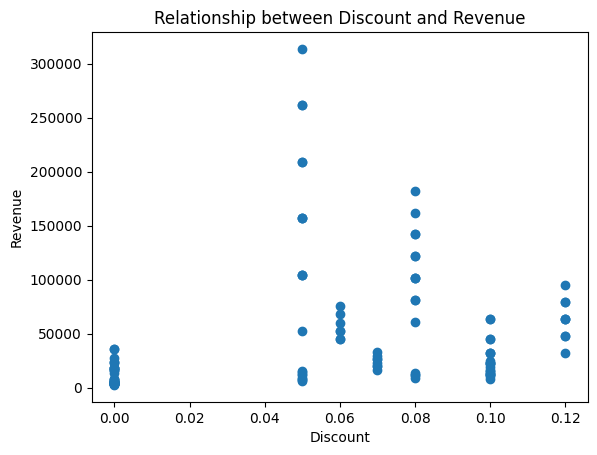

In [12]:
plt.scatter(df["discount"],df["revenue"])
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.title("Relationship between Discount and Revenue")
plt.show()

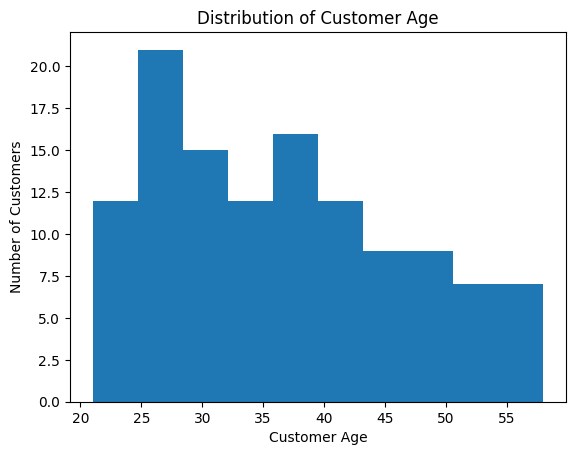

In [13]:
plt.hist(df["customer_age"], bins = 10)
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Age")
plt.show()

In [14]:
avg_revenue = df.groupby(["category","customer_gender"])["revenue"].mean()
print(avg_revenue)

category     customer_gender
Clothing     Female              13485.125000
             Male                11623.750000
Electronics  Female              80213.043478
             Male               112093.000000
Furniture    Female              28333.333333
             Male                28444.444444
Grocery      Female               5705.555556
             Male                 4136.000000
Name: revenue, dtype: float64


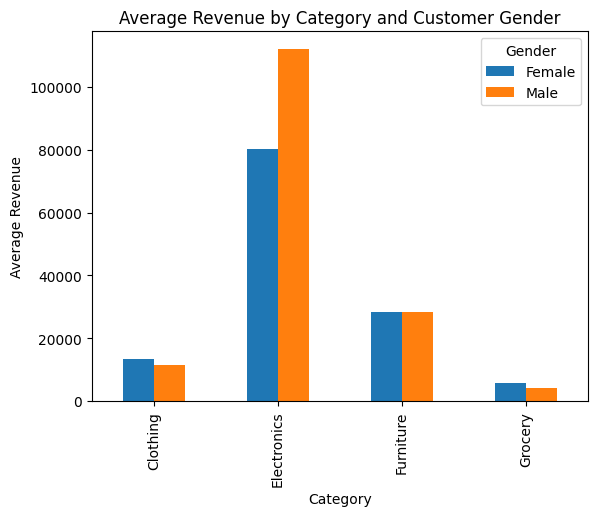

In [15]:
avg_revenue.unstack().plot(kind = "bar")
plt.xlabel("Category")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Category and Customer Gender")
plt.legend(title = "Gender")
plt.show()

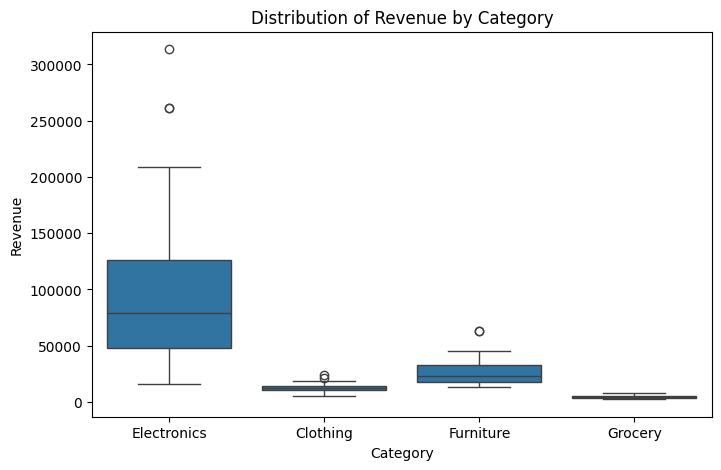

In [16]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = "category", y = "revenue", data = df)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Distribution of Revenue by Category")
plt.show()

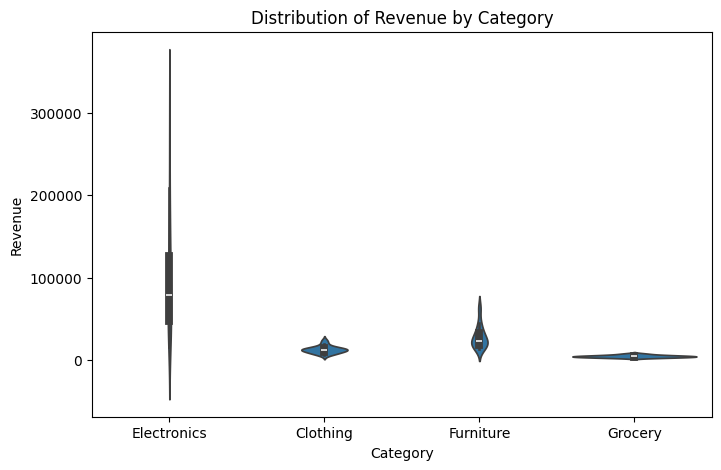

In [17]:
plt.figure(figsize = (8, 5))
sns.violinplot(x = "category", y = "revenue", data = df)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Distribution of Revenue by Category")
plt.show()

In [23]:
print(df.columns.tolist())

['order_id', 'date', 'region', 'category', 'product', 'units_sold', 'unit_price', 'discount', 'revenue', 'customer_age', 'customer_gender', 'payment_mode', 'returns', 'month']


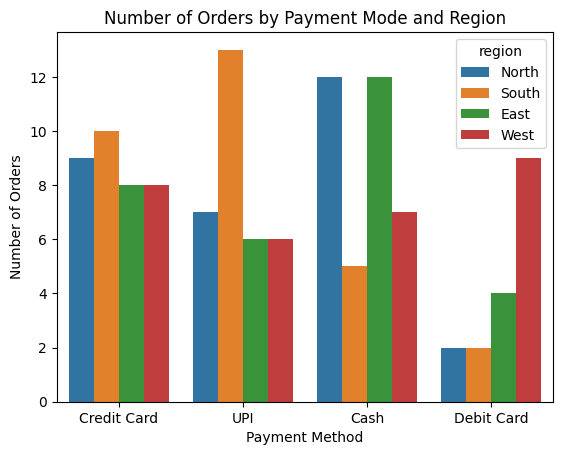

In [24]:
sns.countplot(x="payment_mode", hue="region", data=df)

plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Payment Mode and Region")
plt.show()

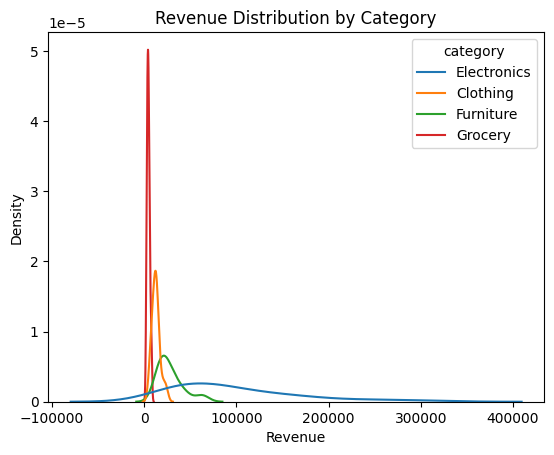

In [25]:
sns.kdeplot(data=df, x="revenue", hue="category")

plt.xlabel("Revenue")
plt.ylabel("Density")
plt.title("Revenue Distribution by Category")
plt.show()

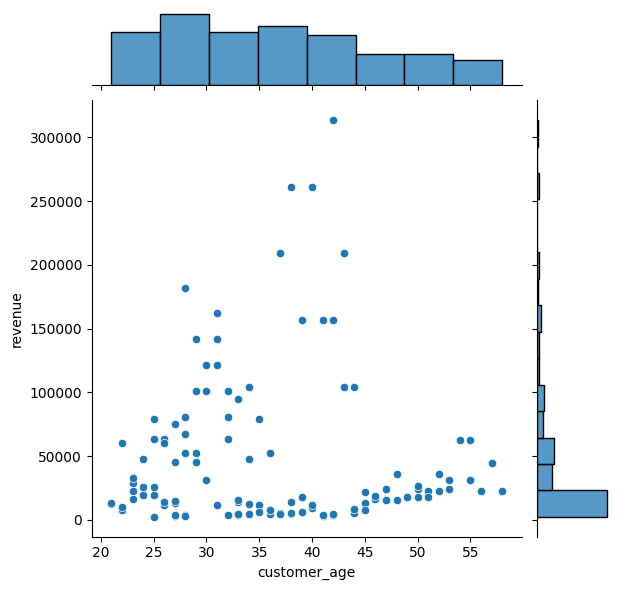

In [26]:
sns.jointplot(data=df, x="customer_age", y="revenue", kind="scatter")
plt.show()

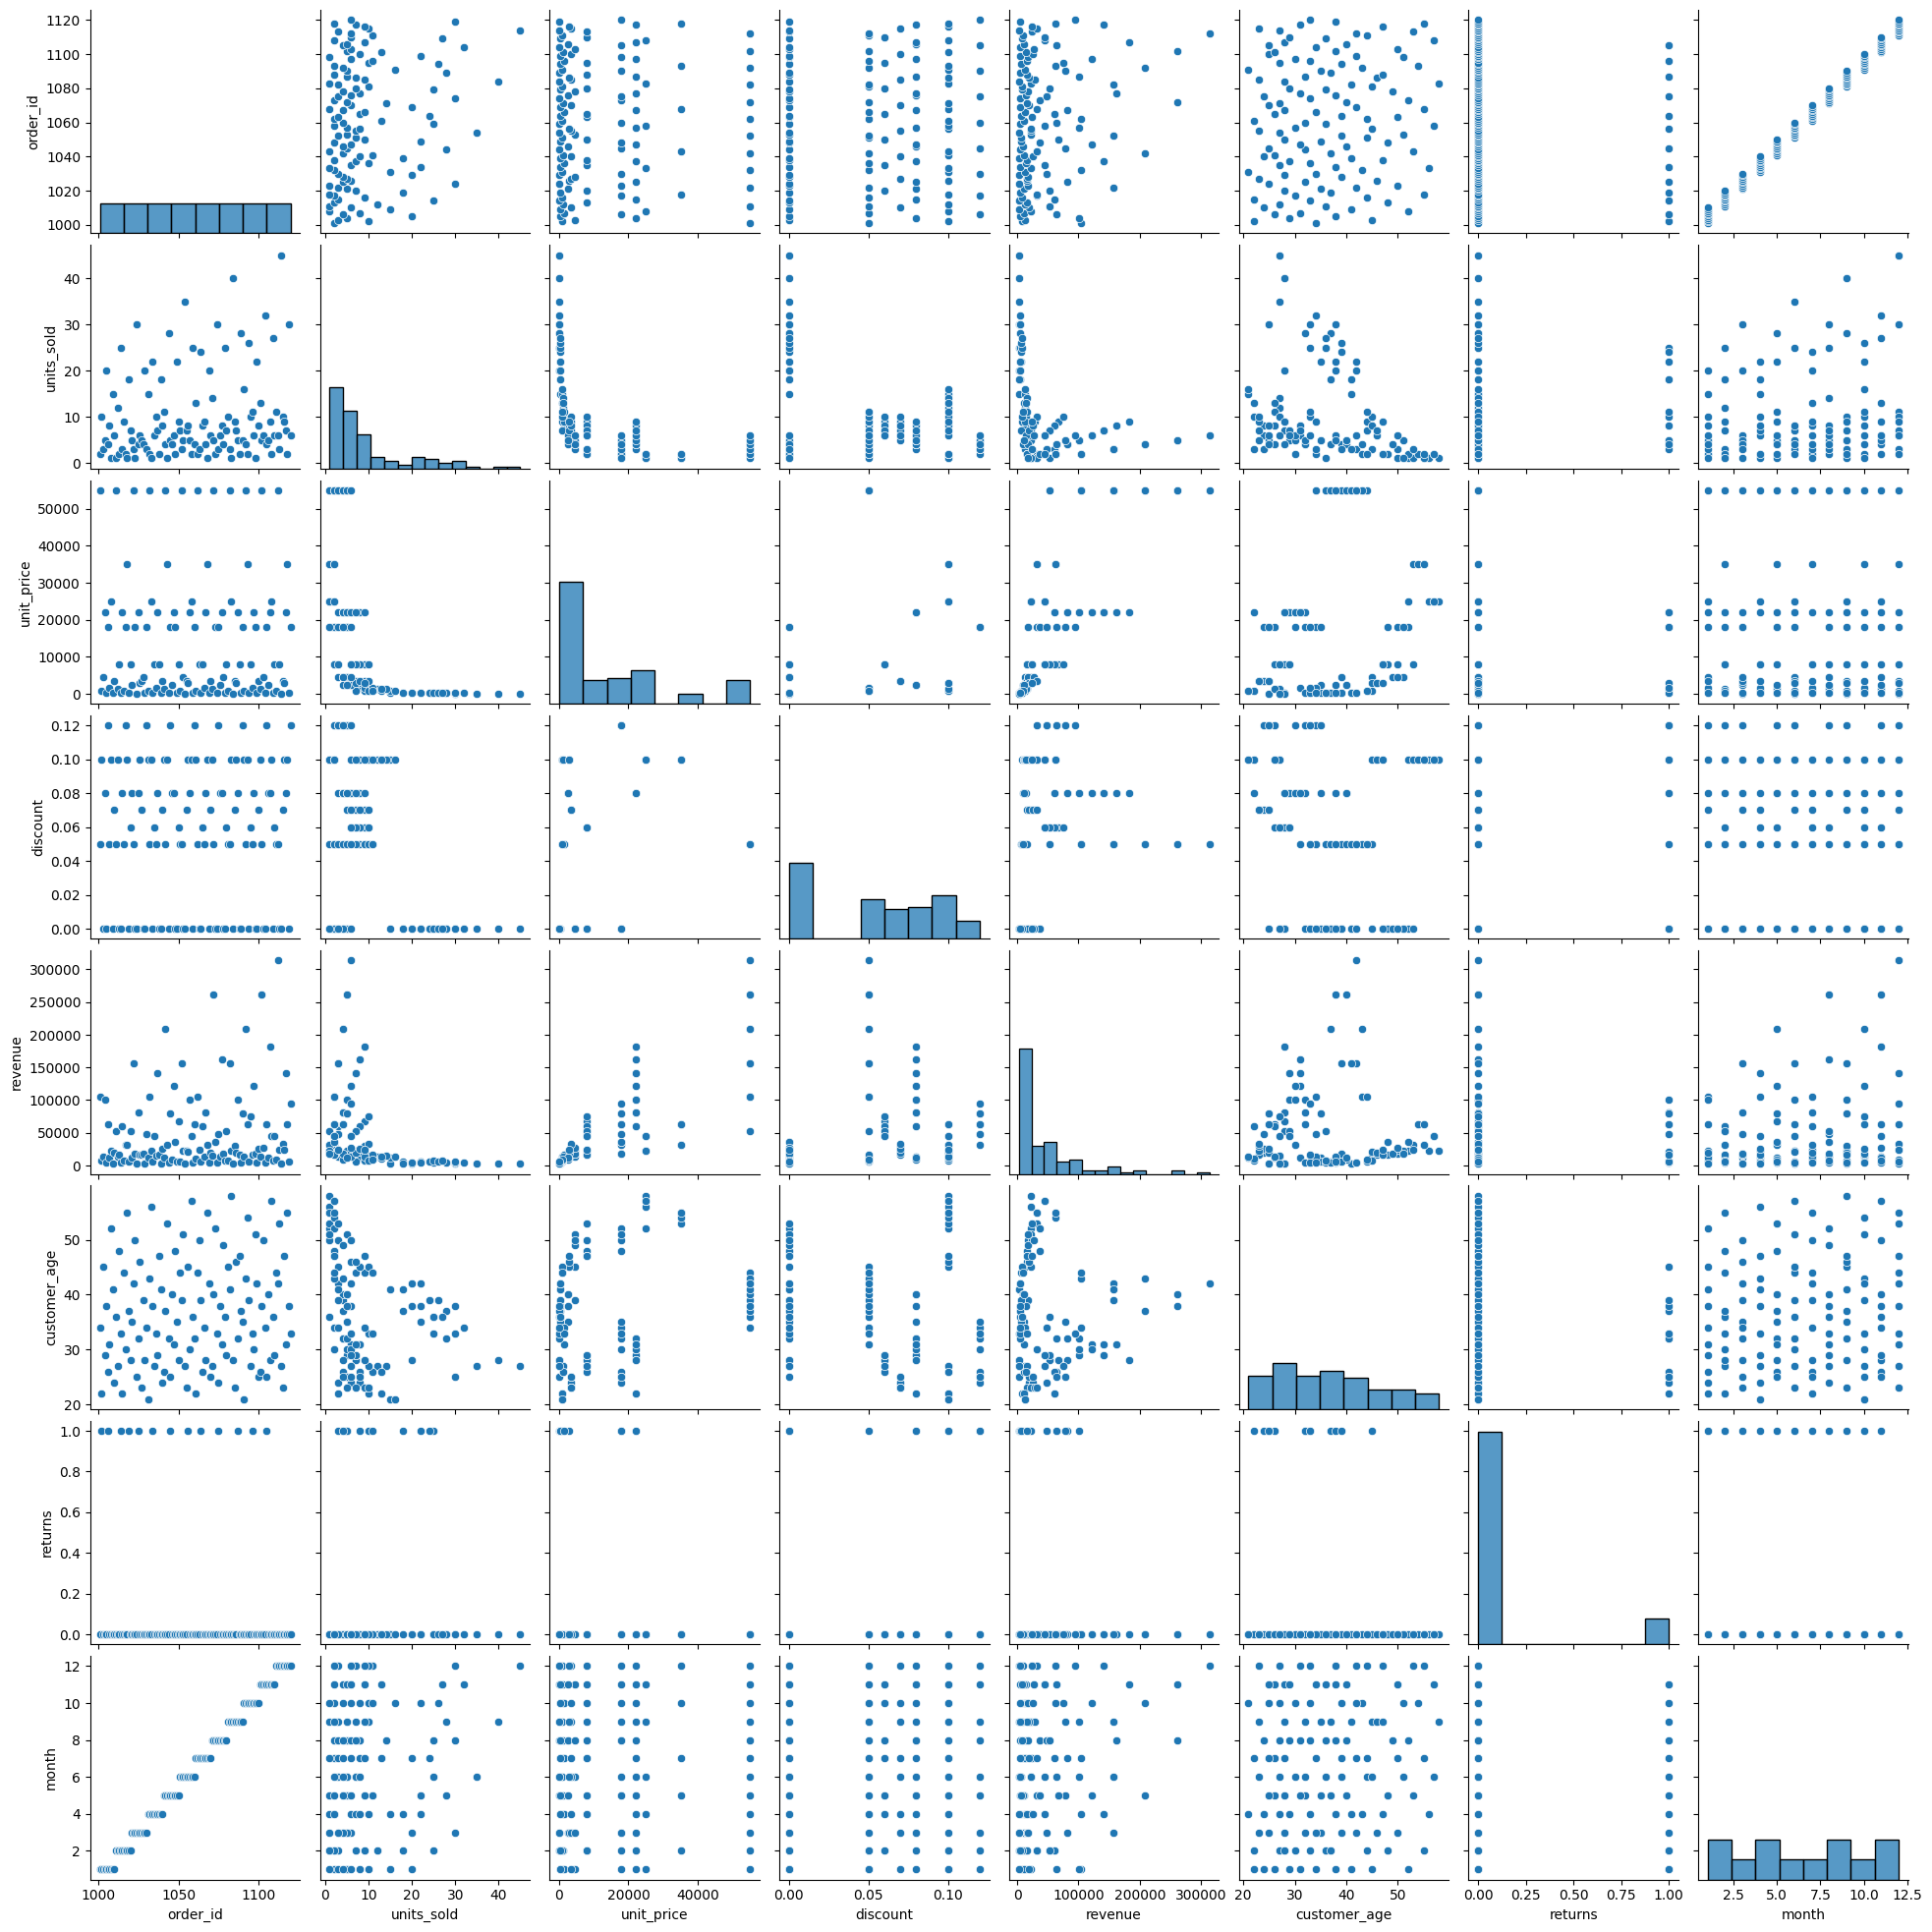

In [27]:
sns.pairplot(df.select_dtypes(include="number"))
plt.show()

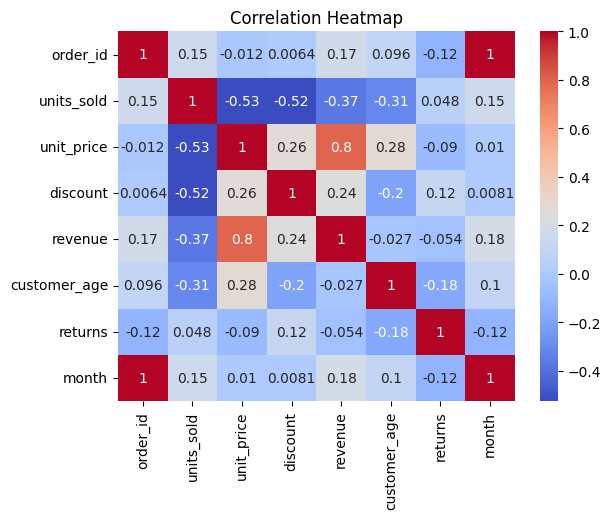

In [28]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()